In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devdgohil/the-oxfordiiit-pet-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset


In [2]:
import os
import json

In [3]:
img_dir = "/kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images"
mask_dir = "/kaggle/input/datasets/mrheavenly/masks-oxford"

config_path = "/kaggle/working/master_config.json"

ae_weights_path = "/kaggle/input/models/mrheavenly/ae-model/pytorch/default/1/best_weights_ae.pth"

ext_path = "/kaggle/input/models/mrheavenly/ext-weights1/pytorch/default/1/best_weights.pth"


In [4]:
# Create directories in the writable /working path
!mkdir -p /kaggle/working/clean_pet_data/images
!mkdir -p /kaggle/working/clean_pet_data/masks

# Note: Ensure these paths match your actual input structure
!cp -r /kaggle/input/datasets/devdgohil/the-oxfordiiit-pet-dataset/images/images/* /kaggle/working/clean_pet_data/images/
!cp -r /kaggle/input/datasets/mrheavenly/masks-oxford/* /kaggle/working/clean_pet_data/masks/

In [5]:
import os
import shutil
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# --- PATHS ---
# Source (Read-Only)
SRC_IMG_DIR = img_dir
SRC_MASK_DIR = mask_dir

# Destination (Writable)
IMG_DIR = '/kaggle/working/clean_pet_data/images'
MASK_DIR = '/kaggle/working/clean_pet_data/masks'

def is_corrupted_binary(filepath):
    """Step 2: Check raw binary for truncation (Missing FF D9)."""
    try:
        if os.path.getsize(filepath) == 0:
            return True
        if filepath.lower().endswith(('.jpg', '.jpeg')):
            with open(filepath, 'rb') as f:
                f.seek(-2, 2)
                if f.read() != b'\xff\xd9':
                    return True
        return False
    except Exception:
        return True

def sanitize_and_clean():
    """Step 3: Binary cleanup and Metadata stripping via re-encoding."""
    SUPPORTED = {'.jpg', '.jpeg', '.png', '.webp', '.gif'}
    img_files = [f for f in os.listdir(IMG_DIR) if os.path.splitext(f)[1].lower() in SUPPORTED]
    
    corrupted_count = 0
    sanitized_count = 0
    
    print(f"Processing {len(img_files)} images...")

    for img_name in img_files:
        img_path = os.path.join(IMG_DIR, img_name)
        base_name = os.path.splitext(img_name)[0]
        
        # Match mask
        mask_path = None
        for suffix in ['.png', '_mask.png']:
            temp_path = os.path.join(MASK_DIR, base_name + suffix)
            if os.path.exists(temp_path):
                mask_path = temp_path
                break

        # Check for binary corruption (truncation)
        if is_corrupted_binary(img_path) or (mask_path and is_corrupted_binary(mask_path)):
            print(f"  [DELETING] {base_name} (Truncated)")
            if os.path.exists(img_path): os.remove(img_path)
            if mask_path and os.path.exists(mask_path): os.remove(mask_path)
            corrupted_count += 1
            continue

        # Re-encode to strip "extraneous bytes" warnings
        if img_path.lower().endswith(('.jpg', '.jpeg')):
            try:
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img.save(img_path, 'JPEG', quality=100, subsampling=0)
                sanitized_count += 1
            except Exception as e:
                print(f"  [DELETING] {base_name} (Re-encode failed: {e})")
                if os.path.exists(img_path): os.remove(img_path)
                if mask_path: os.remove(mask_path)
                corrupted_count += 1

    print("-" * 40)
    print(f"Cleanup Finished.")
    print(f"Total Deleted (Corrupt): {corrupted_count}")
    print(f"Total Re-encoded (Sanitized): {sanitized_count}")

if __name__ == '__main__':
    sanitize_and_clean()

Processing 7390 images...
  [DELETING] Egyptian_Mau_14 (Truncated)
  [DELETING] Egyptian_Mau_186 (Truncated)
  [DELETING] Egyptian_Mau_145 (Truncated)
  [DELETING] Abyssinian_34 (Truncated)
  [DELETING] Egyptian_Mau_139 (Truncated)
  [DELETING] Egyptian_Mau_167 (Truncated)
  [DELETING] Egyptian_Mau_177 (Truncated)
  [DELETING] Egyptian_Mau_191 (Truncated)
  [DELETING] Egyptian_Mau_156 (Truncated)
  [DELETING] Egyptian_Mau_138 (Truncated)
  [DELETING] Abyssinian_5 (Truncated)
----------------------------------------
Cleanup Finished.
Total Deleted (Corrupt): 11
Total Re-encoded (Sanitized): 7379


In [6]:
print(len(os.listdir(IMG_DIR)))
print(len(os.listdir(MASK_DIR)))

7382
7379


In [8]:
config_path = "/kaggle/working/master_config.json"

if os.path.exists(config_path):
    with open(config_path, "r") as f:
        master_config = json.load(f)
    print("Existing master_config.json loaded.")
else:
    master_config = {}
    print("master_config.json not found. Creating a new one.")

master_config["stage4_gan"] = {
    "images_dir": IMG_DIR,
    "mask_dir": MASK_DIR,
    "checkpoint_dir": "/kaggle/working/checkpoints_gan",
    "best_model_dir": "/kaggle/working/best_model_gan",
    
    # Weights
    "ae_weights": ae_weights_path,
    "ext_weights": ext_path, 
    
    # Dataset & Multiprocessing
    "img_size": 224,
    "num_workers": 4, # Set to 4 as requested
    
    # Hyperparameters
    "batch_size": 4,
    "max_iterations": 60,
    "lr_g": 0.0001,
    "lr_d": 0.00005,
    "weight_decay": 0.0001,
    "accum_steps": 4,
    
    # Loss Weights
    "lambda_l1": 10.0,
    "lambda_ext": 5.0,
    "lambda_gan": 1.0,
    
    # Training Dynamics
    "attack_p": 0.8,
    "attack_warmup_epochs": 2,
    "patience": 15,
    "min_delta": 0.0001,
    "save_every": 5
}

# 3. Save it back safely
with open(config_path, "w") as f:
    json.dump(master_config, f, indent=2)


print("Stage 4 GAN config updated successfully in master_config.json!")

master_config.json not found. Creating a new one.
Stage 4 GAN config updated successfully in master_config.json!


In [9]:
import json
import os

config_path = "/kaggle/working/master_config.json"

print("--- 1. CONFIGURATION READOUT ---")
try:
    with open(config_path, "r") as f:
        check_config = json.load(f)
    
    stage4 = check_config.get("stage4_gan", {})
    # Print the config to visually ensure the variables injected correctly
    print(json.dumps(stage4, indent=2))
    print("\n✅ Config successfully loaded and formatted.")

    print("\n--- 2. CRITICAL PATH VERIFICATION ---")
    paths_to_check = [
        ("Images Directory", stage4.get("images_dir")),
        ("Masks Directory", stage4.get("mask_dir")),
        ("Stage 2b Autoencoder Weights", stage4.get("ae_weights")),
        ("Stage 3 Extractor Weights", stage4.get("ext_weights"))
    ]

    all_good = True
    for name, path in paths_to_check:
        if path and os.path.exists(path):
            print(f"✅ FOUND: {name}")
        else:
            print(f"❌ MISSING: {name}\n   -> Path checked: {path}")
            all_good = False

    print("\n--- STATUS ---")
    if all_good:
        print("🚀 ALL SYSTEMS GO! Every file is in place. You are cleared to run train_gan.py.")
    else:
        print("🛑 STOP! One or more paths are broken. Fix them before starting Stage 4.")

except FileNotFoundError:
    print(f"❌ CRITICAL ERROR: The master_config.json file was not found at {config_path}")

--- 1. CONFIGURATION READOUT ---
{
  "images_dir": "/kaggle/working/clean_pet_data/images",
  "mask_dir": "/kaggle/working/clean_pet_data/masks",
  "checkpoint_dir": "/kaggle/working/checkpoints_gan",
  "best_model_dir": "/kaggle/working/best_model_gan",
  "ae_weights": "/kaggle/input/models/mrheavenly/ae-model/pytorch/default/1/best_weights_ae.pth",
  "ext_weights": "/kaggle/input/models/mrheavenly/ext-weights1/pytorch/default/1/best_weights.pth",
  "img_size": 224,
  "num_workers": 4,
  "batch_size": 4,
  "max_iterations": 60,
  "lr_g": 0.0001,
  "lr_d": 5e-05,
  "weight_decay": 0.0001,
  "accum_steps": 4,
  "lambda_l1": 10.0,
  "lambda_ext": 5.0,
  "lambda_gan": 1.0,
  "attack_p": 0.8,
  "attack_warmup_epochs": 2,
  "patience": 15,
  "min_delta": 0.0001,
  "save_every": 5
}

✅ Config successfully loaded and formatted.

--- 2. CRITICAL PATH VERIFICATION ---
✅ FOUND: Images Directory
✅ FOUND: Masks Directory
✅ FOUND: Stage 2b Autoencoder Weights
✅ FOUND: Stage 3 Extractor Weights

---

In [10]:
!rm -rf /kaggle/working/checkpoints_ext_pt
!rm -rf /kaggle/working/best_model_ext_pt

In [12]:
!python /kaggle/input/models/mrheavenly/asdsad/transformers/default/1/train_gan.py --config /kaggle/working/master_config.json

Loaded Stage 4 Config from master JSON.
[Rank 0] Initializing on Tesla T4
[Rank 1] Initializing on Tesla T4
  [train] 6272 samples | [val] 1107 samples
  Starting Stage 4 GAN training for 60 epochs

Epoch   1/60 | LR_G: 0.000100 | Time: 0:05:05 (Total: 0:05:05)
  Train | Loss_D: 0.8353 | Loss_G: 5.0617 | Corr_O: 0.904 | Corr_B: 0.900
  Val   | Loss_D: 0.8390 | Loss_G: 2.6745 | Corr_O: 0.983 | Corr_B: 0.991
------------------------------------------------------------------------------------------
    [ckpt] Saved → /kaggle/working/checkpoints_gan/best_model.pth
Epoch   2/60 | LR_G: 0.000100 | Time: 0:05:08 (Total: 0:10:14)
  Train | Loss_D: 0.8369 | Loss_G: 2.5054 | Corr_O: 0.989 | Corr_B: 0.992
  Val   | Loss_D: 0.8390 | Loss_G: 2.5881 | Corr_O: 0.977 | Corr_B: 0.983
------------------------------------------------------------------------------------------
    [ckpt] Saved → /kaggle/working/checkpoints_gan/best_model.pth
Epoch   3/60 | LR_G: 0.000100 | Time: 0:05:08 (Total: 0:15:24)
  

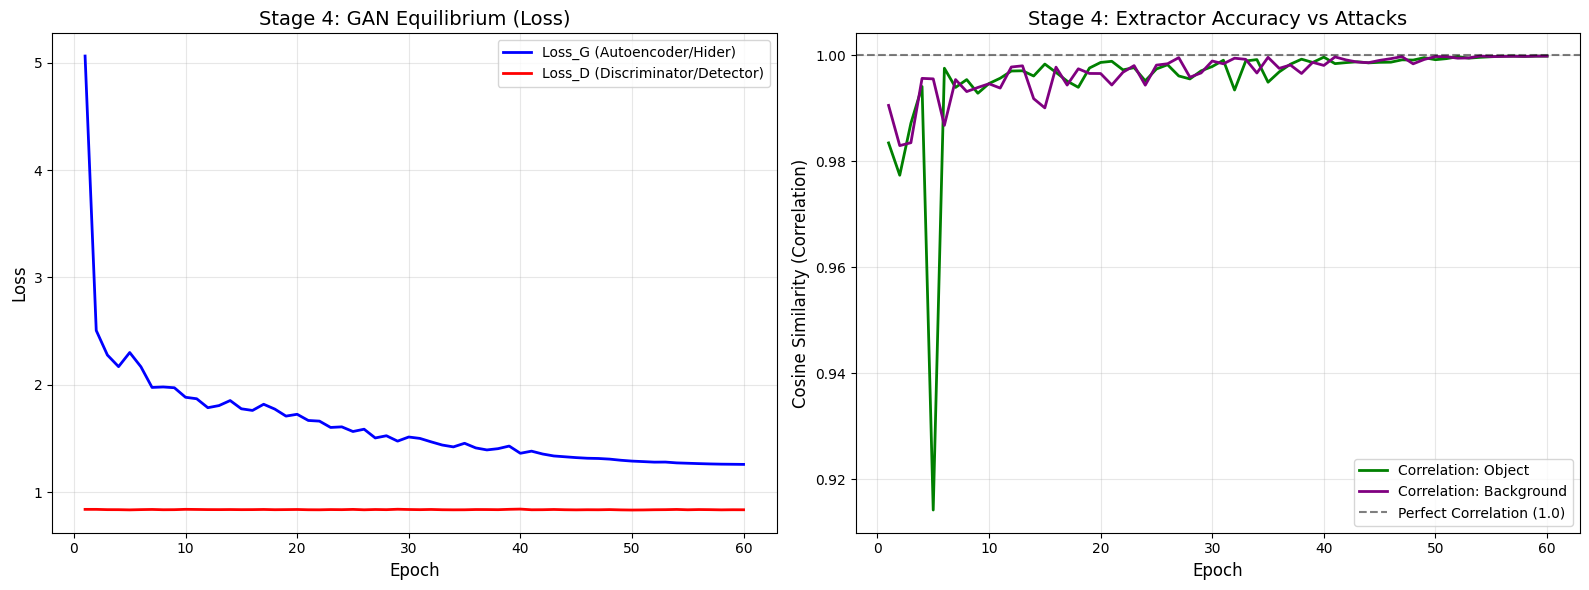

In [15]:
import matplotlib.pyplot as plt

# Load the saved history
history_path = '/kaggle/working/checkpoints_gan/history.json'
with open(history_path, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_total']) + 1)

plt.figure(figsize=(16, 6))

# --- Plot 1: The Adversarial War (Losses) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_total'], label='Loss_G (Autoencoder/Hider)', color='blue', linewidth=2)
plt.plot(epochs, history['breakdown']['loss_d']['val'], label='Loss_D (Discriminator/Detector)', color='red', linewidth=2)
plt.title('Stage 4: GAN Equilibrium (Loss)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# --- Plot 2: Extractor Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history['breakdown']['corr_o']['val'], label='Correlation: Object', color='green', linewidth=2)
plt.plot(epochs, history['breakdown']['corr_b']['val'], label='Correlation: Background', color='purple', linewidth=2)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Perfect Correlation (1.0)')
plt.title('Stage 4: Extractor Accuracy vs Attacks', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cosine Similarity (Correlation)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("history_plot_gan.png")
plt.show()

Loading Stage 4 Models...
Models loaded successfully.

Testing image: Sphynx_245.jpg

Saved visualization -> stage4_inference_result.png


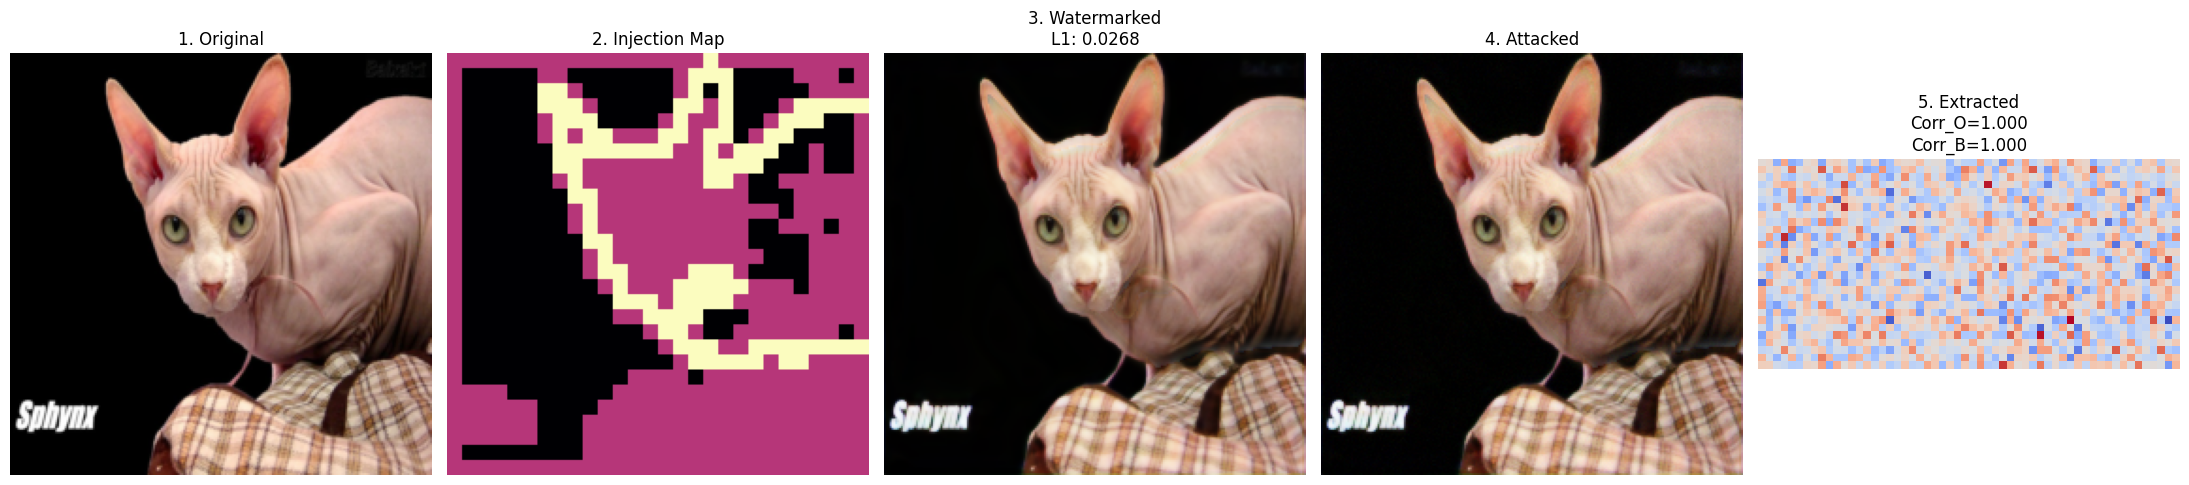


================ DEBUG =================
L1 Error          : 0.026755
Corr Object       : 0.999889
Corr Background   : 0.999866

Recovered Watermark Stats:
Object Mean       : 0.000300
Object Std        : 0.000141
Background Mean   : 0.000308
Background Std    : 0.000152
Object abs mean: 0.0003019185969606042
Background abs mean: 0.0003105590585619211
MSE Obj: 0.02022477239370346
MSE BG : 0.019947035238146782


In [22]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.io import read_image
import matplotlib.pyplot as plt
import os
import random
import sys

# =============================================================================
# IMPORT YOUR ARCHITECTURES
# =============================================================================

sys.path.insert(0, "/kaggle/input/models/mrheavenly/asdsad/transformers/default/1")

import train_gan as gan
import train_extractor_scratch as ex

# =============================================================================
# CONFIG
# =============================================================================

IMG_DIR = "/kaggle/working/clean_pet_data/images"
MASK_DIR = "/kaggle/working/clean_pet_data/masks"

AE_WEIGHTS = "/kaggle/working/best_model_gan/ae_best_weights.pth"
EXT_WEIGHTS = "/kaggle/working/best_model_gan/ext_best_weights.pth"

IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# HELPERS
# =============================================================================

def denorm(x):
    """
    Convert [-1,1] -> [0,1]
    """
    return ((x + 1.0) * 0.5).clamp(0, 1)

def to_pil(t):
    """
    Tensor -> PIL image
    """
    return TF.to_pil_image(denorm(t.squeeze(0)).cpu())

# =============================================================================
# LOAD MODELS
# =============================================================================

print("Loading Stage 4 Models...")

# ---------------- AE ----------------

ae = gan.DAE(lat=256).to(device)

ae_state = torch.load(AE_WEIGHTS, map_location=device)

ae.load_state_dict(
    gan.clean_state(ae_state.get("model", ae_state)),
    strict=False
)

ae.eval()

# ---------------- Extractor ----------------

ext = ex.HeavyWatermarkDecoder(num_res_blocks=6).to(device)

ext_state = torch.load(EXT_WEIGHTS, map_location=device)

ext.load_state_dict(
    gan.clean_state(ext_state.get("model", ext_state)),
    strict=True
)

ext.eval()

# ---------------- Injector ----------------

inj = gan.SSInj(256, 28, 28).to(device)
inj.eval()

# ---------------- Utilities ----------------

edge = gan.EdgeMask().to(device)
edge.eval()

atk = gan.AttackLayer(p=1.0).to(device)
atk.eval()

print("Models loaded successfully.\n")

# =============================================================================
# LOAD RANDOM IMAGE
# =============================================================================

SUPPORTED = {".jpg", ".jpeg", ".png"}

img_files = [
    f for f in os.listdir(IMG_DIR)
    if os.path.splitext(f)[1].lower() in SUPPORTED
]

random_img_name = random.choice(img_files)

base_name = os.path.splitext(random_img_name)[0]

img_path = os.path.join(IMG_DIR, random_img_name)

mask_path = os.path.join(MASK_DIR, base_name + ".png")

if not os.path.exists(mask_path):
    mask_path = os.path.join(MASK_DIR, base_name + "_mask.png")

print(f"Testing image: {random_img_name}")

# =============================================================================
# PREPROCESS
# =============================================================================

img = read_image(img_path)

if img.shape[0] == 4:
    img = img[:3]

elif img.shape[0] == 1:
    img = img.repeat(3, 1, 1)

img = img.float() / 255.0

mask = read_image(mask_path)[0:1]
mask = (mask.float() > 127.0).float()

# Resize

img = TF.resize(img, [IMG_SIZE, IMG_SIZE])

mask = TF.resize(
    mask,
    [IMG_SIZE, IMG_SIZE],
    interpolation=TF.InterpolationMode.NEAREST
)

# IMPORTANT: SAME NORMALIZATION AS TRAINING

img = TF.normalize(
    img,
    [0.5, 0.5, 0.5],
    [0.5, 0.5, 0.5]
)

img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

# =============================================================================
# INFERENCE
# =============================================================================

with torch.inference_mode():

    # ---------------- Split object/background ----------------

    objs = img * mask
    bgs = img * (1.0 - mask)

    # ---------------- Soft mask ----------------

    soft_m = TF.gaussian_blur(
        mask,
        [15, 15],
        [5.0, 5.0]
    )

    # ---------------- Edge maps ----------------

    em_o = edge(objs)
    em_b = edge(bgs)

    # ---------------- Watermark ----------------
    # IMPORTANT:
    # Use SAME alpha values as training

    wm_o, wm_b = ae.forward_watermarked(
        objs,
        bgs,
        inj,
        0.5,
        3.5,
        em_o,
        em_b
    )

    wm_img = (
        wm_o * soft_m
        + wm_b * (1.0 - soft_m)
    )

    # ---------------- Attack ----------------

    atk_img = atk(
        wm_img,
        ep=100,
        wp=0
    )

    # ---------------- Extract ----------------

    pwm, _ = ext(atk_img, soft_m)

    # =============================================================================
    # TARGET WATERMARKS
    # =============================================================================

    tw1 = inj.w1.mean(1, keepdim=True).expand(
        1, -1, -1, -1
    )

    tw2 = inj.w2.mean(1, keepdim=True).expand(
        1, -1, -1, -1
    )

    po = pwm[:, 0:1]
    pb = pwm[:, 1:2]

    to = tw1
    tb = tw2

    # =============================================================================
    # METRICS
    # =============================================================================

    co = F.cosine_similarity(
        po.flatten(1),
        to.flatten(1)
    ).item()

    cb = F.cosine_similarity(
        pb.flatten(1),
        tb.flatten(1)
    ).item()

    l1_err = F.l1_loss(wm_img, img).item()

# =============================================================================
# VISUALIZATION
# =============================================================================

plt.figure(figsize=(22, 6))

# -----------------------------------------------------------------------------
# Original
# -----------------------------------------------------------------------------

plt.subplot(1, 5, 1)

plt.imshow(to_pil(img))

plt.title("1. Original")

plt.axis("off")

# -----------------------------------------------------------------------------
# Injection Map
# -----------------------------------------------------------------------------

plt.subplot(1, 5, 2)

edge_vis = F.interpolate(
    em_o + em_b,
    size=(IMG_SIZE, IMG_SIZE),
    mode="nearest"
)

plt.imshow(
    edge_vis.squeeze().cpu(),
    cmap="magma"
)

plt.title("2. Injection Map")

plt.axis("off")

# -----------------------------------------------------------------------------
# Watermarked
# -----------------------------------------------------------------------------

plt.subplot(1, 5, 3)

plt.imshow(to_pil(wm_img))

plt.title(
    f"3. Watermarked\nL1: {l1_err:.4f}"
)

plt.axis("off")

# -----------------------------------------------------------------------------
# Attacked
# -----------------------------------------------------------------------------

plt.subplot(1, 5, 4)

plt.imshow(to_pil(atk_img))

plt.title("4. Attacked")

plt.axis("off")

# -----------------------------------------------------------------------------
# Recovered Watermarks
# -----------------------------------------------------------------------------

plt.subplot(1, 5, 5)

combined = torch.cat([
    po[0],
    pb[0]
], dim=-1)

combined = combined.detach().cpu()

plt.imshow(combined.squeeze(), cmap="coolwarm")

plt.title(
    f"5. Extracted\nCorr_O={co:.3f}\nCorr_B={cb:.3f}"
)

plt.axis("off")

plt.tight_layout()

save_path = "stage4_inference_result.png"

plt.savefig(save_path, dpi=200)

print(f"\nSaved visualization -> {save_path}")

plt.show()

# =============================================================================
# EXTRA DEBUG INFO
# =============================================================================

print("\n================ DEBUG =================")

print(f"L1 Error          : {l1_err:.6f}")
print(f"Corr Object       : {co:.6f}")
print(f"Corr Background   : {cb:.6f}")

print("\nRecovered Watermark Stats:")
print(f"Object Mean       : {po.mean().item():.6f}")
print(f"Object Std        : {po.std().item():.6f}")

print(f"Background Mean   : {pb.mean().item():.6f}")
print(f"Background Std    : {pb.std().item():.6f}")

print("========================================")

print("Object abs mean:", po.abs().mean().item())
print("Background abs mean:", pb.abs().mean().item())

mse_o = F.mse_loss(po, to).item()
mse_b = F.mse_loss(pb, tb).item()

print("MSE Obj:", mse_o)
print("MSE BG :", mse_b)

In [16]:
import shutil
import os
from IPython.display import FileLink, display

def backup_training_run():
    # Paths to your saved folders
    best_dir = '/kaggle/working/best_model_gan'
    ckpt_dir = '/kaggle/working/checkpoints_gan'
    
    # 1. Zip the Best Model Directory
    if os.path.exists(best_dir):
        shutil.make_archive('best_model_e2e_backup', 'zip', best_dir)
        print("✅ Zipped Best Model successfully!")
        display(FileLink('best_model_e2e_backup.zip'))
    else:
        print(f"❌ Could not find {best_dir}")

    # 2. Zip the Checkpoints Directory
    if os.path.exists(ckpt_dir):
        shutil.make_archive('checkpoints_e2e_backup', 'zip', ckpt_dir)
        print("✅ Zipped Checkpoints successfully!")
        display(FileLink('checkpoints_e2e_backup.zip'))
    else:
        print(f"❌ Could not find {ckpt_dir}")

# Run the function
backup_training_run()

✅ Zipped Best Model successfully!


/kaggle/working/best_model_e2e_backup.zip

✅ Zipped Checkpoints successfully!


/kaggle/working/checkpoints_e2e_backup.zip

In [ ]:
os.listdir('/kaggle/working/checkpoints_gan')